In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(url)

# Quick look at data
df.head()


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


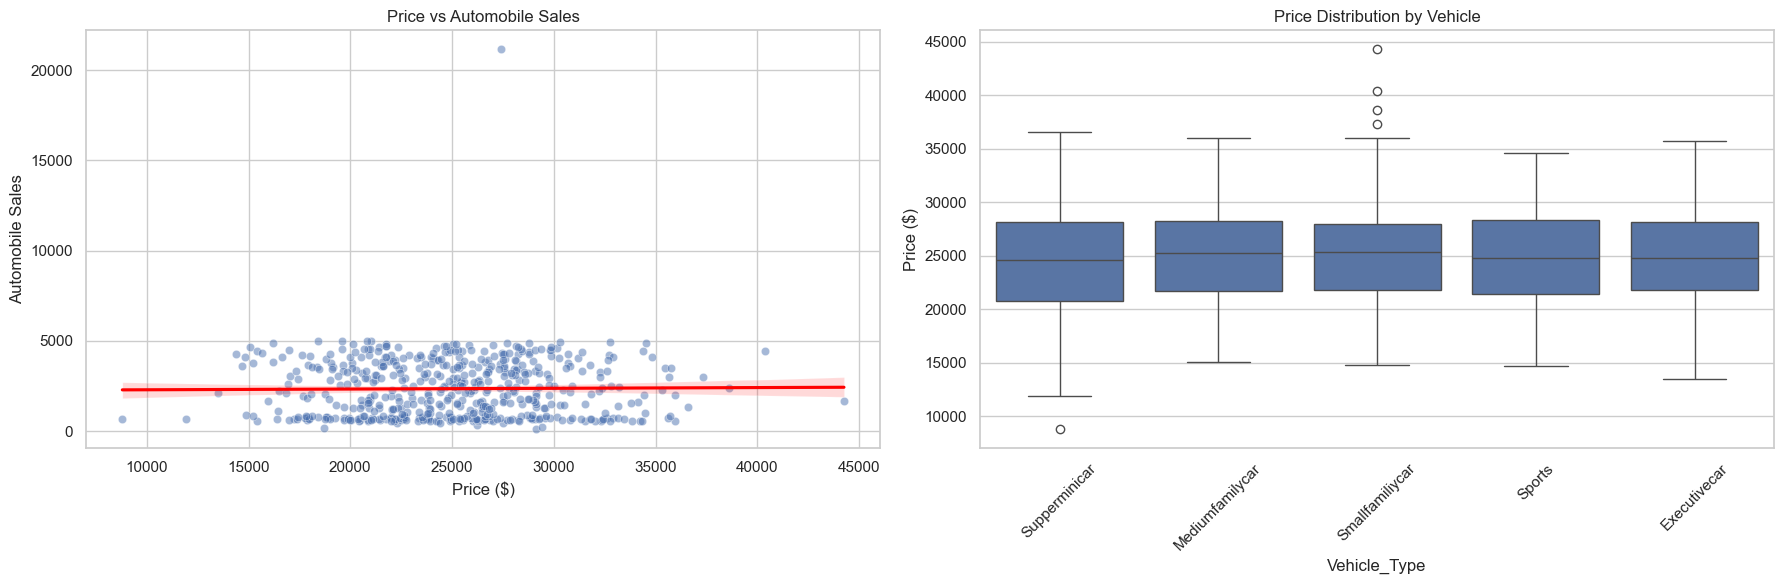

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter Plot: Price vs Automobile Sales
sns.scatterplot(data=df, x='Price', y='Automobile_Sales', ax=axes[0], alpha=0.5)
sns.regplot(data=df, x='Price', y='Automobile_Sales', scatter=False, ax=axes[0], color='red')
axes[0].set_title("Price vs Automobile Sales")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Automobile Sales")

# Boxplot: Price Distribution by Brand
sns.boxplot(data=df, x='Vehicle_Type', y='Price', ax=axes[1])
axes[1].set_title("Price Distribution by Vehicle")
axes[1].set_xlabel("Vehicle_Type")
axes[1].set_ylabel("Price ($)")
axes[1].tick_params(axis='x', rotation=45)  # Rotate brand names for readability

# Adjust layout
plt.tight_layout()
plt.show()


In [6]:
fig.savefig("eda_scatter_boxplot_autosales.png", dpi=300)


    Year  Automobile_Sales
0   1980           8147.40
1   1981           7600.90
2   1982           7573.80
3   1983          34672.20
4   1984          35667.00
5   1985          38113.60
6   1986          28093.60
7   1987          27458.00
8   1988          36894.00
9   1989          38971.30
10  1990          11007.30
11  1991           7870.70
12  1992          19772.40
13  1993          24279.00
14  1994          30657.90
15  1995          51603.00
16  1996          27542.50
17  1997          33482.90
18  1998          35938.70
19  1999          30752.20
20  2000          15441.50
21  2001           8305.60
22  2002          21398.60
23  2003          31547.90
24  2004          37786.60
25  2005          36918.80
26  2006          30691.80
27  2007          32726.00
28  2008          15474.60
29  2009           7580.30
30  2010          27703.20
31  2011          39915.60
32  2012          33386.60
33  2013          29767.00
34  2014          40354.90
35  2015          40226.80
3

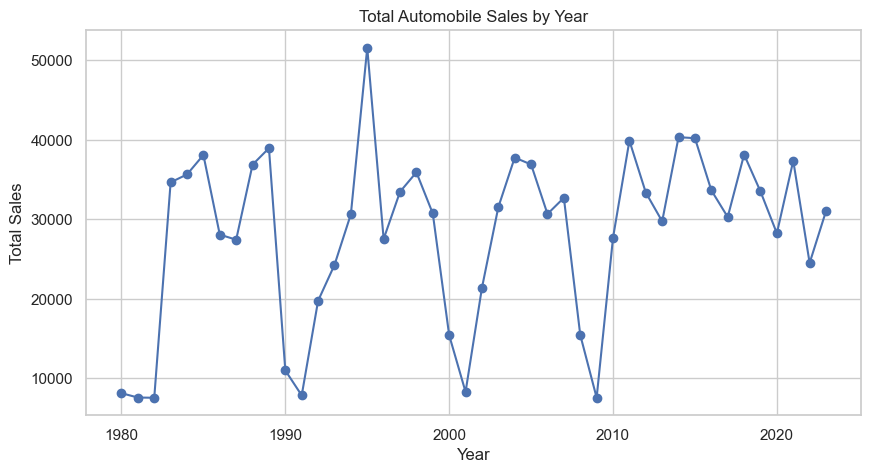

In [8]:
# Total sales per year
sales_by_year = df.groupby('Year')['Automobile_Sales'].sum().reset_index()
sales_by_year = sales_by_year.sort_values('Year')

print(sales_by_year)

# Optional: visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(sales_by_year['Year'], sales_by_year['Automobile_Sales'], marker='o')
plt.title("Total Automobile Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


         City  Automobile_Sales
0    New York         353913.50
1    Illinois         319408.00
2     Georgia         290418.64
3  California         278495.00


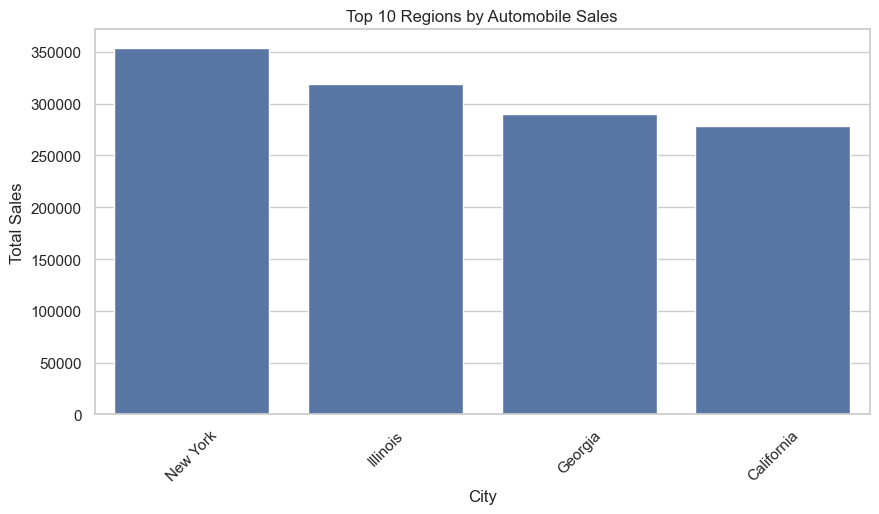

In [11]:
# Total sales per region
sales_by_region = df.groupby('City')['Automobile_Sales'].sum().sort_values(ascending=False).reset_index()
print(sales_by_region)

# Optional: bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=sales_by_region.head(10), x='City', y='Automobile_Sales')  # top 10 regions
plt.title("Top 10 Regions by Automobile Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


   Quarter  Automobile_Sales
0        1         309232.14
1        2         313429.30
2        3         303013.40
3        4         316560.30


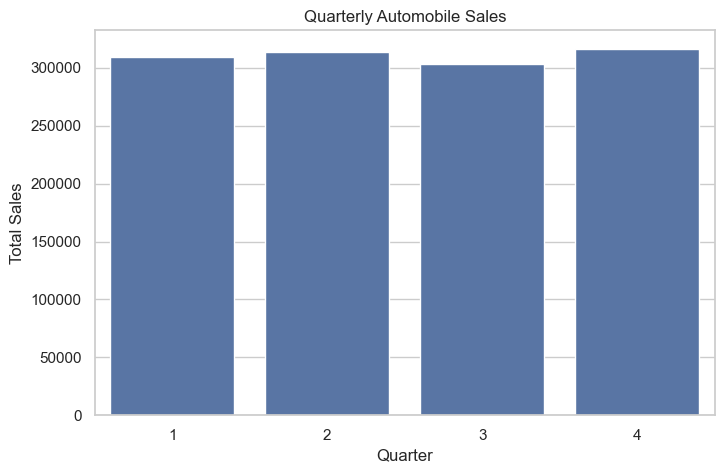

In [14]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract quarter
df['Quarter'] = df['Date'].dt.quarter

# Total sales per quarter
sales_by_quarter = df.groupby('Quarter')['Automobile_Sales'].sum().reset_index()
print(sales_by_quarter)

# Optional: bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=sales_by_quarter, x='Quarter', y='Automobile_Sales')
plt.title("Quarterly Automobile Sales")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Select features (replace column names if needed)
features = ['Price', 'Year', 'Vehicle_Type']  # key predictors
target = 'Automobile_Sales'

# For categorical variables like Brand or Vehicle_Type, convert to numeric using get_dummies
X = pd.get_dummies(df[features], drop_first=True)
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
# Create and fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)
print("R²:", r2)


R²: -0.018753439808364192


In [17]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 1327.5732687641103


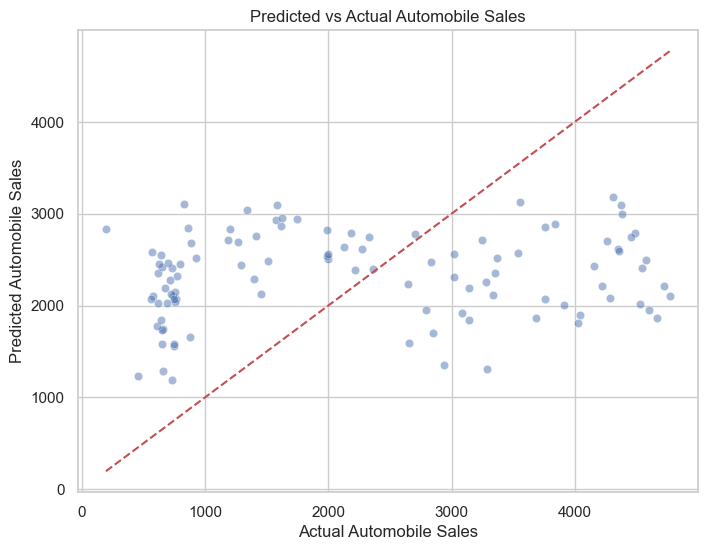

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.xlabel("Actual Automobile Sales")
plt.ylabel("Predicted Automobile Sales")
plt.title("Predicted vs Actual Automobile Sales")
plt.show()


In [19]:
# Get feature coefficients
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(10))  # top features


                        Feature  Coefficient
4           Vehicle_Type_Sports    88.898712
1                          Year    18.155373
0                         Price    -0.006692
2  Vehicle_Type_Mediumfamilycar  -286.237153
3  Vehicle_Type_Smallfamiliycar  -539.120954
5    Vehicle_Type_Supperminicar -1090.142257
